# Survival Analysis II
# Survival Regression Models

This article is part of a series...
- ...
- ...

# Outline

- Survival Regression Models
- Cox's Proportional Hazards (PH) Model
    - Testing the Proportional Hazards Assumption
    - Stratification
- The Partial AIC
- Train/Test Splitting
- Aalen's Additive Model
- The Concordance Index
- The Brier Score
    - Time-Dependent Brier Score
    - Integrated Brier Score
- Accelerated Failure Time (AFT) Models
    - Weibull AFT Model
    - Log-Normal AFT Model
    - Log-Logistic AFT Model
- Cross-Validation
- Grid Search

# Survival Regression Models

Incorporating continuous covariates into survival models is possible, but involves extending beyond Kaplan-Meier and Nelson-Aalen models. We cannot use traditional regression methods because of censoring, but alternatives such as Cox's proportional hazards model, accelerated failure time (AFT) models, and Aalen's additive model exist. Each of these represent the hazard rate $h(t|\mathbf{X})$ and covariates $\mathbf{X}$.

# Cox's Proportional Hazards (PH) Model

The idea behind Cox's PH model is that the log-hazard of an individual is a linear function of their covariates and a population-level baseline hazard that changes over time.

$\underbrace{h(t | \mathbf{X})}_{\text{hazard}} = \overbrace{\beta_0(t)}^{\text{baseline hazard}}  \underbrace{\exp \overbrace{\left(\sum_{i=1}^n \beta_i (X_i - \overline{X_i})\right)}^{\text{log-partial hazard}}}_ {\text{partial hazard}}$

The time component is the baseline hazard, $\beta_0(t)$. The proportional hazards assumption is that the effect of the covariates does not vary with time.

The key to the Cox model's handling of censoring lies in the partial likelihood approach, which allows censored data to contribute to the estimation process without needing to specify the exact survival time until the event for censored subjects. For individuals who experience the event, the data contribute fully to the likelihood because the exact event time is known, and for individuals who are censored, only the fact that the individuals survived up until a particular time is known. The partial likelihood is derived from the conditional probability of observing an event at a particular time, given that the individual is at risk at that time.

$\mathcal{L}(\beta) = \displaystyle \prod_{i \in \text{events}} \frac{ exp(X_i \beta) }{ \displaystyle \sum_{j \in R(t)} exp(X_i \beta) }$

The numerator represents the contribution to the likelihood from the individual who experiences the count at time $t_i$. The denominator is the sum of hazards for all individuals still at risk a time $t_i$, including both censored and uncensored individuals. $R(t)$ refers to this 'risk set' of individuals.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")
from sklearn.model_selection import train_test_split

C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
from lifelines.datasets import load_gbsg2
data = load_gbsg2()

In [3]:
data['horTh'] = data['horTh'].map({'yes': 1, 'no': 0})
data['menostat'] = data['menostat'].map({'Post': 1, 'Pre': 0})
data['tgrade'] = data['tgrade'].map({'I': 1, 'II': 2, 'III': 3})
data.head()

,horTh,age,menostat,tsize,tgrade,pnodes,progrec,estrec,time,cens
0,0,70,1,21,2,3,48,66,1814,1
1,1,56,1,12,2,7,61,77,2018,1
2,1,58,1,35,2,9,52,271,712,1
3,1,59,1,17,2,4,60,29,1807,1
4,0,73,1,35,2,1,26,65,772,1


In [4]:
from lifelines import CoxPHFitter
cph = CoxPHFitter()
cph.fit(data, duration_col="time", event_col="cens")
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 686 total observations, 387 right-censored observations>
             duration col = 'time'
                event col = 'cens'
      baseline estimation = breslow
   number of observations = 686
number of events observed = 299
   partial log-likelihood = -1737.17
         time fit was run = 2024-12-01 20:23:02 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
horTh     -0.34      0.71      0.13           -0.59           -0.08                0.55                0.92
age       -0.01      0.99      0.01           -0.03            0.01                0.97                1.01
menostat   0.27      1.31      0.18           -0.09            0.63                0.91                1.87
tsize      0.01      1.01      0.00           -0.00            0.02                1.00                1.02
tgrade     0.28      1.32      0.11            0.07            0.49                1.08                1.63
pnodes     0.05      1.05      0.01            0.04            0.06                1.04                1.07
progrec   -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
estrec     0.00      1.00      0.00           -0.00            0.00                1.00                1.00

           cmp to     z      p  -log2(p)
covariate                               
horTh        0.00 -2.61   0.01      6.81
age          0.00 -1.01   0.31      1.68
menostat     0.00  1.46   0.14      2.79
tsize        0.00  1.95   0.05      4.30
tgrade       0.00  2.64   0.01      6.93
pnodes       0.00  6.73 <0.005     35.82
progrec      0.00 -3.89 <0.005     13.26
estrec       0.00  0.37   0.71      0.50
---
Concordance = 0.69
Partial AIC = 3490.35
log-likelihood ratio test = 101.86 on 8 df
-log2(p) of ll-ratio test = 58.96

<Axes: xlabel='log(HR) (95% CI)'>

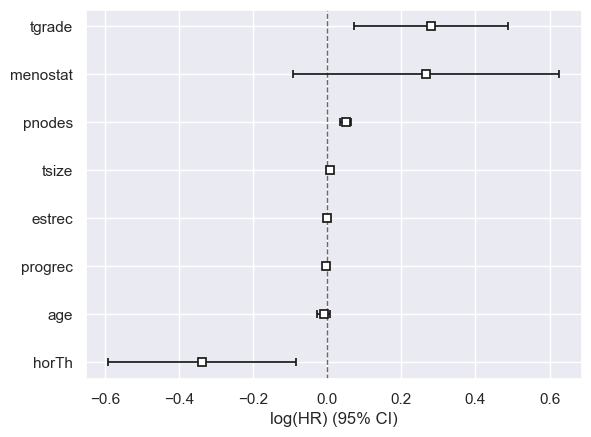

In [5]:
cph.plot()

## Testing the Proportional Hazards Assumption

As mentioned above, the proportional hazards assumption is that the effect of covariates does not vary over time. A usual indicator of a violation of this assumption is if the Kaplan-Meier curves for two covariates cross each other. A statistical test that can be used is the Schoenfield residuals test, which examines whether the residuals from the Cox model are correlated over time. Residuals that are independent of time will produce a p-value greater than $0.05$ (or some threshold), suggesting no significant violation of the PH assumption. $p \le 0.05$ would in that case suggest a violation.

$r_{ij} = x_{ij} - \hat{E}[X_j (t_i)]$

$\hat{E}[X_j (t_i)] = \frac{ \displaystyle \sum_{k \in R(t_i)} x_{kj} e^{\hat{\beta}^T x_k} }{ \displaystyle \sum_{k \in R(t_i)} e^{\hat{\beta}^T x_k} }$

- $r_{ij}$ is the residual for individual $i$, covariate $j$, time $t_i$.
- $z_{ij}$ is the observed value for individual $i$, covariate $j$, time $t_i$.
- $\hat{E}[X_j t(i)]$ is the weighted mean of covariate $j$ over all individuals in the risk set at time $t_i$, weighted by their estimated hazard contributions.
- $\hat{\beta}$ is the estimated coefficients of the model.

The test is implemented as <code>proportional_hazard_test</code> in lifelines.

In [6]:
from lifelines.statistics import proportional_hazard_test

results = proportional_hazard_test(cph, data, time_transform='rank')
results.print_summary(decimals=3, model="untransformed variables")

<lifelines.StatisticalResult: proportional_hazard_test>
    time_transform = rank
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 686 total observations, 387 right-censored observations>
         test_name = proportional_hazard_test

---
          test_statistic    p  -log2(p)
age                 2.65 0.10      3.27
estrec              1.32 0.25      2.00
horTh               0.17 0.68      0.55
menostat            0.03 0.87      0.20
pnodes              0.70 0.40      1.31
progrec             1.25 0.26      1.92
tgrade              5.57 0.02      5.78
tsize               0.24 0.62      0.68

## Stratification

If the proportional hazards assumption does not hold, one strategy is to stratify by the offending covariate.

$h_s(t, X(s)) = h_{0,s}(t) ~exp(\beta^T X(s))$

The categories s are used to stratify the subjects into S groups for which a Cox model is fitted. For each strata-specific hazard function, one can define a partial likelihood function $\mathcal{L}_s(\beta)$. The overall partial likelihood function for all strata is then given by the product of the individual likelihoods.

$\mathcal{L}(\beta) = \displaystyle \prod_{s=1}^S \mathcal{L}_s(\beta)$

In [7]:
from lifelines import CoxPHFitter
cph = CoxPHFitter()
cph.fit(data, duration_col="time", event_col="cens", strata="tgrade")
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 686 total observations, 387 right-censored observations>
             duration col = 'time'
                event col = 'cens'
                   strata = tgrade
      baseline estimation = breslow
   number of observations = 686
number of events observed = 299
   partial log-likelihood = -1507.00
         time fit was run = 2024-12-01 20:23:02 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
horTh     -0.35      0.70      0.13           -0.61           -0.10                0.54                0.90
age       -0.01      0.99      0.01           -0.03            0.01                0.97                1.01
menostat   0.27      1.30      0.18           -0.10            0.63                0.91                1.87
tsize      0.01      1.01      0.00            0.00            0.02                1.00                1.02
pnodes     0.05      1.05      0.01            0.03            0.06                1.03                1.06
progrec   -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
estrec     0.00      1.00      0.00           -0.00            0.00                1.00                1.00

           cmp to     z      p  -log2(p)
covariate                               
horTh        0.00 -2.73   0.01      7.31
age          0.00 -1.01   0.31      1.68
menostat     0.00  1.44   0.15      2.74
tsize        0.00  2.12   0.03      4.86
pnodes       0.00  6.34 <0.005     31.98
progrec      0.00 -3.79 <0.005     12.71
estrec       0.00  0.35   0.72      0.47
---
Concordance = 0.67
Partial AIC = 3027.99
log-likelihood ratio test = 78.13 on 7 df
-log2(p) of ll-ratio test = 44.78

# The Partial AIC

The partial AIC (Akaike Information Criterion) is a variant of the AIC that focuses on the model's ability to explain the event-related component of the data, while ignoring terms related to censoring or baseline hazards. The partial AIC focuses only on the portion of the log-likelihood associated with the event times, excluding contributions from censored data.

$\text{AIC} = - 2 \cdot \text{log-likelihood} + 2k$
- $k$ is the number of parameters

$\text{Partial AIC} = -2 \cdot \ell_{events} + 2k$

$\ell_{events} = \sum_{i=1}^n \delta_i ~log(h(t_i|\mathbf{x}_i) - \displaystyle \int_0^{t_i} h(u|\mathbf{x}_i) ~du$

- $\delta_i$ is the event indicator
- $h(t|\mathbf{x})$ is the hazard function at time t given covariates \mathbf{x}
- $t_i$ is the time observed for the $i^{th}$ individual. The integral accounts for the cumulative hazard contribution of events. As with the standard AIC, the $2k$ term penalizes overfitting.

In [8]:
data_subset = data.drop(columns=['age', 'estrec'])
cph = CoxPHFitter()
cph.fit(data_subset, duration_col="time", event_col="cens")
log_likelihood = cph.log_likelihood_
num_params = cph.params_.shape[0]  # Number of covariates
partial_aic = -2 * log_likelihood + 2 * num_params
partial_aic

3487.4065359296083

In [9]:
data_subset = data.drop(columns=['age', 'estrec', 'menostat'])
cph = CoxPHFitter()
cph.fit(data_subset, duration_col="time", event_col="cens")
log_likelihood = cph.log_likelihood_
num_params = cph.params_.shape[0]  # Number of covariates
partial_aic = -2 * log_likelihood + 2 * num_params
partial_aic

3486.661153283365

In [10]:
# Train/Test Splitting

In [11]:
X = data.drop(['cens', 'time', 'age', 'estrec', 'menostat'], axis=1)
y = data[['cens', 'time']]

x_train, x_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, stratify=y["cens"], random_state=0
)

train = pd.concat((x_train, y_train), axis=1)
test = pd.concat((x_test, y_test), axis=1)

cph.fit(train, duration_col="time", event_col="cens")
cph_preds = cph.predict_partial_hazard(test)

## Aalen's Additive Model

Aalen's additive model is an additive linear model, with time-varying coefficients. As such, it is not constrained by the proportional hazards assumption. The hazard function $h(t|\mathbf{X}(t))$ at time $t$, given a set of covariates $\mathbf{X} = (X_1(t), X_2(t), \ldots, X_p(t))$ is modeled as:

$h(t|\mathbf{X}(t)) = h_0(t) + \displaystyle \sum_{i=1}^p \beta_j(t) X_i(t)$

- $h_0(t)$ is the time-dependent baseline hazard function
- $\beta_j(t)$ is the time-varying regression coefficient for covariate $X_j(t)$
- $X_j(t)$ is covariate $j$ at time $t$

In [14]:
from lifelines import AalenAdditiveFitter

aaf = AalenAdditiveFitter()
aaf.fit(train,  duration_col="time", event_col="cens")
aaf_preds = aaf.predict_survival_function(test)

# The Concordance Index

The concordance index, also known as Harrell's c-statistic, or the c-index, is a measure of rank correlation between predicted risk scores and observed time points, defined as the ratio of correctly ordered (concordant) pairs to comparable pairs.

$\text{c-index} = \frac{\text{# concordant pairs}}{\text{# comparable pairs}}$

- concordant pair: the model correctly orders them
- comparable pair: neither individuals are censored before the event of interest

This is closely related to Kendall's tau, but accounts for censoring by considering only comparable pairs. A limitation is that, although it evaluates discrimination, it does not evaluate calibration, i.e., how well the predicted probabilities match the natural probabilities.

Because Harrell's concordance index is known to be biased upwards if the amount of censoring is high, Uno et al. (**link**) proposed an alternative estimator that behaves better in such situations. scikit-survival implements the former with _____, and the latter with <code>concordance_index_ipcw</code>.

In [15]:
print(cph.concordance_index_)
print(aaf.concordance_index_)

0.692666454134344
0.5072674246986174


# The Brier Score

The Brier score is calculated as the mean square error between the predicted probability and actual outcome for each observation. In doing so, it focuses on how well the model predicts event probabilities, rather than just ranks.

$BS = \frac{1}{n} \displaystyle \sum_{i=1}^n (\hat{y}_i - y_i)^2$

The Brier score ranges from 0 to 1, with 0 representing perfect predictions, and 0.5 representing no better than random guessing.


## Time-Dependent Brier Score

For each time point, the time-dependent Brier score measures how close the predicted survival probability is to the actual outcome, considering the likelihood of the event happening by that time.

$BS(t) = \frac{1}{n} \displaystyle \sum_{i=1}^n I(y_i \lt t \cap \delta_i = 1) \frac{ (0 - \hat{\pi}(t|x_i))^2 }{ \hat{G}(y_i) } + I(y_i \gt t) \frac{ (1 - \hat{\pi}(t|\mathbf{x}_i))^2 }{ \hat{G}(t) }$

- $\hat{\pi}_i(t)$ is the predicted survival probability at time $t$ for individual $i$.

- $I(T_i \le t)$ is an indicator function equal to $1$ if the event occurred for individual $i$ and time $t$.

- $\hat{G}(t)$ is the survival function.


## Integrated Brier Score

The integrated Brier score provides a single summary measure of the prediction error over a range of time points.

$IBS = \displaystyle \int_{t_1}^{t_{max}} BS(t) ~dw(t)$

where the weighting function is $w(t)$, such as $w(t) = t/t_{max}$.

In [16]:
from sksurv.metrics import integrated_brier_score

In [18]:
from sksurv.util import Surv

duration_train = y_train['time']
event_train = y_train['cens'].astype(bool)
y_sksurv_train = Surv.from_arrays(event_train, duration_train)

duration_test = y_test['time']
event_test = y_test['cens'].astype(bool)
y_sksurv_test = Surv.from_arrays(event_test, duration_test)

In [19]:
cph = CoxPHFitter()
cph.fit(train, 'time', 'cens')
time_min = y_test['time'].min()
time_max = y_test['time'].max()
times = np.arange(time_min, time_max, len(y_test))
cph_preds = cph.predict_survival_function(x_test, times)

IBS = integrated_brier_score(y_sksurv_train, y_sksurv_test, cph_preds.T, times)
IBS

0.17682871155627042

In [20]:
aaf = AalenAdditiveFitter()
aaf.fit(train,  duration_col="time", event_col="cens")
aaf_preds = aaf.predict_survival_function(test)

IBS = integrated_brier_score(y_sksurv_train, y_sksurv_test, aaf_preds.T, aaf_preds.index)
IBS

0.18483149269885354

## Accelerated Failure Time (AFT) Models

An AFT model relates the survival function of two different populations $A$ and $B$ by an accelerated failure rate, $\lambda$.

$S_A(t) = S_B \left( \frac{t}{\lambda} \right)$

For example, dogs age at a rate 7 times that of humans, so $S_D(t) = S_H \left( \frac{t}{7} \right)$

We can model $\lambda$ as a function of covariates.

$S_A(t) = S_B \left( \frac{t}{\lambda(x)} \right)$

$\lambda(x) = exp \left( \beta_0 + \displaystyle \sum_{i=1}^n \beta_i x_i \right)$

Next, we pick a parametric form for the survival function $S(t)$.

### Weibull AFT Model

If we assume the Weibull form the hazard function is:

$H(t,x,y) = \left( \frac{t}{\lambda(x)} \right)^{\rho(y)}$

With the lifelines AFT models, if the argument <code>model_ancillary</code> is set to true, then the shape parameter $\rho$ is modeled as a function of covariates in addition to the scale parameter $\lambda$. Otherwise, the ancillary parameter \rho is treated as fixed.


### Log-Normal AFT Model

If we assume the log-normal form, the hazard function is:

$H(t,x,y) = - log \left( 1 - \Phi \left( \frac{ log(T) - \mu(x) }{ \sigma(y) } \right) \right)$

$\mu$ is modeled as a function of covariates, and $\sigma$ is the ancillary parameter.


### Log-Logistic AFT Model

If we assume the log-logistic form, the hazard function is:

$H(t,x,y) = log \left( 1 + \left( \frac{t}{\alpha(x)} \right)^{\beta(y)} \right)$

$\alpha$ is modeled as a function of covariates, and $\beta$ is the ancillary parameter.

In [21]:
from lifelines import WeibullAFTFitter
from lifelines import LogLogisticAFTFitter
from lifelines import LogNormalAFTFitter

weibull_aft = WeibullAFTFitter()
weibull_aft.fit(train, duration_col="time", event_col="cens")

loglog_aft = LogLogisticAFTFitter()
loglog_aft.fit(train, duration_col="time", event_col="cens")

lognormal_aft = LogNormalAFTFitter()
lognormal_aft.fit(train, duration_col="time", event_col="cens")

<lifelines.LogNormalAFTFitter: fitted with 548 total observations, 309 right-censored observations>

In [22]:
weibull_aft_pred = weibull_aft.predict_survival_function(x_test)
loglog_aft_pred = loglog_aft.predict_survival_function(x_test)
lognormal_aft_pred = lognormal_aft.predict_survival_function(x_test)

In [23]:
y_test_min = y_test['time'].min()
y_test_max = y_test['time'].max()
times = np.linspace(y_test_min+0.1, y_test_max-0.1, len(weibull_aft_pred.index))

IBS_weibull_aft = integrated_brier_score(y_sksurv_train, y_sksurv_test, weibull_aft_pred.T, times)
IBS_loglog_aft = integrated_brier_score(y_sksurv_train, y_sksurv_test, loglog_aft_pred.T, times)
IBS_lognormal_aft = integrated_brier_score(y_sksurv_train, y_sksurv_test, lognormal_aft_pred.T, times)

print(IBS_weibull_aft)
print(IBS_loglog_aft)
print(IBS_lognormal_aft)

0.17929128187608415
0.17801258555209296
0.178499224132974


In [ ]:
# cross validation

In [25]:
from lifelines.utils import k_fold_cross_validation

cph = CoxPHFitter()
aaf_1 = AalenAdditiveFitter(coef_penalizer=0.5)  # L2 Regularization
aaf_2 = AalenAdditiveFitter(coef_penalizer=0.1)  # L2 Regularization
weibull_aft = WeibullAFTFitter()
loglog_aft = LogLogisticAFTFitter()
lognormal_aft = LogNormalAFTFitter()

print('cph:           ', np.mean(k_fold_cross_validation(cph, data, duration_col='time', event_col='cens', scoring_method="concordance_index")))
print('aaf_1:         ', np.mean(k_fold_cross_validation(aaf_1, data, duration_col='time', event_col='cens', scoring_method="concordance_index")))
print('aaf_2:         ', np.mean(k_fold_cross_validation(aaf_2, data, duration_col='time', event_col='cens', scoring_method="concordance_index")))
print('weibull_aft:   ', np.mean(k_fold_cross_validation(weibull_aft, data, duration_col='time', event_col='cens', scoring_method="concordance_index")))
print('loglog_aft:    ', np.mean(k_fold_cross_validation(loglog_aft, data, duration_col='time', event_col='cens', scoring_method="concordance_index")))
print('lognormal_aft: ', np.mean(k_fold_cross_validation(lognormal_aft, data, duration_col='time', event_col='cens', scoring_method="concordance_index")))

cph:            0.6768273403982478
aaf_1:          0.6318136691523101
aaf_2:          0.6219358061643779
weibull_aft:    0.678310701762407
loglog_aft:     0.6822402285470021
lognormal_aft:  0.6790501632509148


In [ ]:
# grid search

In [26]:
penalties = [0.01, 0.1, 0.25, 0.5]

for penalty in penalties:
    cph = CoxPHFitter(penalizer=penalty) 
    score = np.mean(k_fold_cross_validation(cph, data, duration_col='time', event_col='cens', scoring_method="concordance_index"))
    print('Penalty ', penalty, ' Score ', score)

Penalty  0.01  Score  0.6753818426227772
Penalty  0.1  Score  0.6717022195239231
Penalty  0.25  Score  0.671943389538104
Penalty  0.5  Score  0.6785078190070316


In [27]:
loglog_aft = LogLogisticAFTFitter()

for penalty in penalties:
    loglog_aft = LogLogisticAFTFitter(penalizer=penalty) 
    score = np.mean(k_fold_cross_validation(loglog_aft, data, duration_col='time', event_col='cens', scoring_method="concordance_index"))
    print('Penalty ', penalty, ' Score ', score)

Penalty  0.01  Score  0.6834640531945486
Penalty  0.1  Score  0.6750605550631963
Penalty  0.25  Score  0.6810990567596148
Penalty  0.5  Score  0.6716274796532927
